In [19]:
import os
os.chdir("/Users/pauldunham/career_projects/opportunity_insights_associate_data_scientist_data_task/data")

In [20]:
import os
os.getcwd()

'/Users/pauldunham/career_projects/opportunity_insights_associate_data_scientist_data_task/data'

In [25]:
df.shape

(19, 33)

In [26]:
df['kid_race'].unique()

array(['All', 'White', 'Black', 'Asian', 'Hispanic', 'AIAN', 'Other'],
      dtype=object)

Child Income Distributions

Black
Q1: 0.3032
Q2: 0.3432
Q3: 0.1978
Q4: 0.1012
Q5: 0.0545
Total: 1.0000

White
Q1: 0.1512
Q2: 0.1635
Q3: 0.1995
Q4: 0.2344
Q5: 0.2514
Total: 1.0000


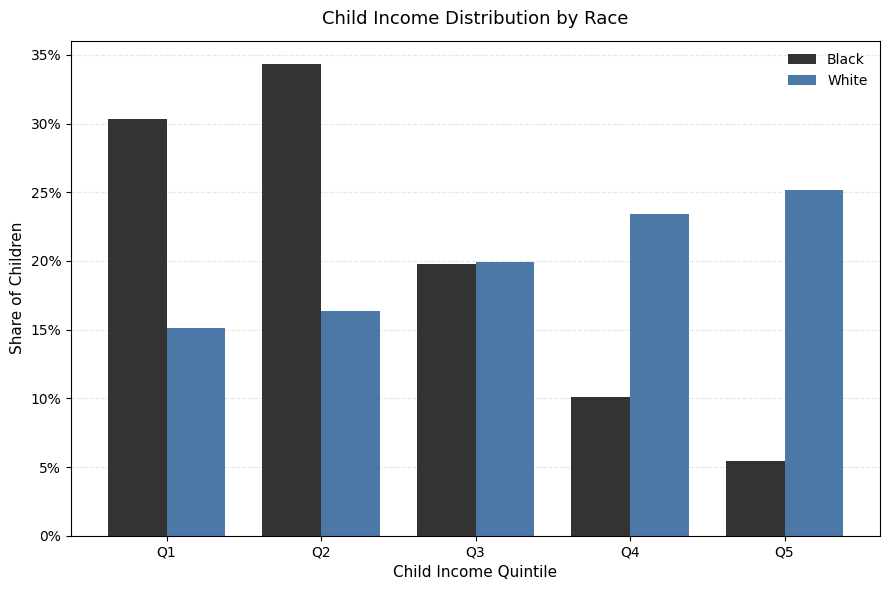

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# QUESTION 3.1
# Construct the distribution of children's income
# by race using the parental income distribution and
# race-specific intergenerational transition matrices.
# Races and income quintiles used throughout the analysis

races = ["Black", "White"]
quintiles = ["Q1", "Q2", "Q3", "Q4", "Q5"]

# 1. Extract parental income distributions
# Each parental distribution contains the share of parents
# in each income quintile.

parent_dist = {}

for race in races:

    row = df_filtered[
        df_filtered["kid_race"] == race
    ].iloc[0]

    parent_dist[race] = row[
        ["par_q1", "par_q2", "par_q3", "par_q4", "par_q5"]
    ].to_numpy(dtype=float)

# 2. Construct race-specific transition matrices
# Rows    = child's income quintile
# Columns = parent's income quintile
# Therefore:
# P[i,j] = Pr(child is in quintile i |
#             parent is in quintile j)

transition = {}

for race in races:

    row = df_filtered[
        df_filtered["kid_race"] == race
    ].iloc[0]

    transition[race] = np.array([

        [
            row["kfr_q1_cond_par_q1"],
            row["kfr_q1_cond_par_q2"],
            row["kfr_q1_cond_par_q3"],
            row["kfr_q1_cond_par_q4"],
            row["kfr_q1_cond_par_q5"]
        ],

        [
            row["kfr_q2_cond_par_q1"],
            row["kfr_q2_cond_par_q2"],
            row["kfr_q2_cond_par_q3"],
            row["kfr_q2_cond_par_q4"],
            row["kfr_q2_cond_par_q5"]
        ],

        [
            row["kfr_q3_cond_par_q1"],
            row["kfr_q3_cond_par_q2"],
            row["kfr_q3_cond_par_q3"],
            row["kfr_q3_cond_par_q4"],
            row["kfr_q3_cond_par_q5"]
        ],

        [
            row["kfr_q4_cond_par_q1"],
            row["kfr_q4_cond_par_q2"],
            row["kfr_q4_cond_par_q3"],
            row["kfr_q4_cond_par_q4"],
            row["kfr_q4_cond_par_q5"]
        ],

        [
            row["kfr_q5_cond_par_q1"],
            row["kfr_q5_cond_par_q2"],
            row["kfr_q5_cond_par_q3"],
            row["kfr_q5_cond_par_q4"],
            row["kfr_q5_cond_par_q5"]
        ]

    ], dtype=float)

# 3. Check the input distributions and transition matrices

for race in races:

    # Parent distribution should sum approximately to 1
    assert np.isclose(
        parent_dist[race].sum(),
        1.0,
        atol=0.001
    ), f"{race} parent distribution is not approximately 1."

    # Each column of the transition matrix should sum
    # approximately to 1.
    column_sums = transition[race].sum(axis=0)

    assert np.allclose(
        column_sums,
        1.0,
        atol=0.001
    ), f"{race} transition matrix columns are not approximately 1."

# 4. Calculate children's income distributions
#
# ChildDist = TransitionMatrix @ ParentDist

child_dist = {}

for race in races:

    child_dist[race] = (
        transition[race] @ parent_dist[race]
    )

    # The source probabilities are rounded, so the resulting
    # distribution may not sum to exactly 1. Normalize it
    # to obtain a valid probability distribution.
    child_dist[race] = (
        child_dist[race] / child_dist[race].sum()
    )


# 5. Print results

print("Child Income Distributions")
print("=" * 50)

for race in races:

    print(f"\n{race}")

    for quintile, share in zip(
        quintiles,
        child_dist[race]
    ):
        print(f"{quintile}: {share:.4f}")

    print(
        f"Total: {child_dist[race].sum():.4f}"
    )

# 6. Save child income distributions to output folder

df_child_dist = pd.DataFrame({
    "Race": races,
    "Q1": [child_dist[r][0] for r in races],
    "Q2": [child_dist[r][1] for r in races],
    "Q3": [child_dist[r][2] for r in races],
    "Q4": [child_dist[r][3] for r in races],
    "Q5": [child_dist[r][4] for r in races]
})

df_child_dist.to_csv("../output/q3_child_income_distribution.csv", index=False)

# 7. Create bar graph

x = np.arange(len(quintiles))
bar_width = 0.38

fig, ax = plt.subplots(
    figsize=(9, 6)
)

# Black children
ax.bar(
    x - bar_width / 2,
    child_dist["Black"],
    width=bar_width,
    label="Black",
    color="#333333"
)

# White children
ax.bar(
    x + bar_width / 2,
    child_dist["White"],
    width=bar_width,
    label="White",
    color="#4C78A8"
)


# Axis labels and title
ax.set_xlabel(
    "Child Income Quintile",
    fontsize=11
)

ax.set_ylabel(
    "Share of Children",
    fontsize=11
)

ax.set_title(
    "Child Income Distribution by Race",
    fontsize=13,
    pad=12
)


# Quintile labels
ax.set_xticks(x)
ax.set_xticklabels(quintiles)


# Format y-axis as percentages
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, _: f"{y:.0%}"
    )
)


# Legend
ax.legend(
    frameon=False
)


# Light horizontal grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

plt.tight_layout()

plt.show()

# 8. Save bar graph to output folder

fig.savefig("../output/q3_child_income_distribution_plot.png", 
            dpi=300, 
            bbox_inches='tight')

Top Income Quintile Share by Generation
Generation         Black       White
------------------------------------
0                 0.0581      0.2632
1                 0.0545      0.2514
2                 0.0561      0.2448
3                 0.0567      0.2424
4                 0.0569      0.2416
5                 0.0569      0.2413
6                 0.0569      0.2413
7                 0.0569      0.2412
8                 0.0569      0.2412
9                 0.0569      0.2412
10                0.0569      0.2412


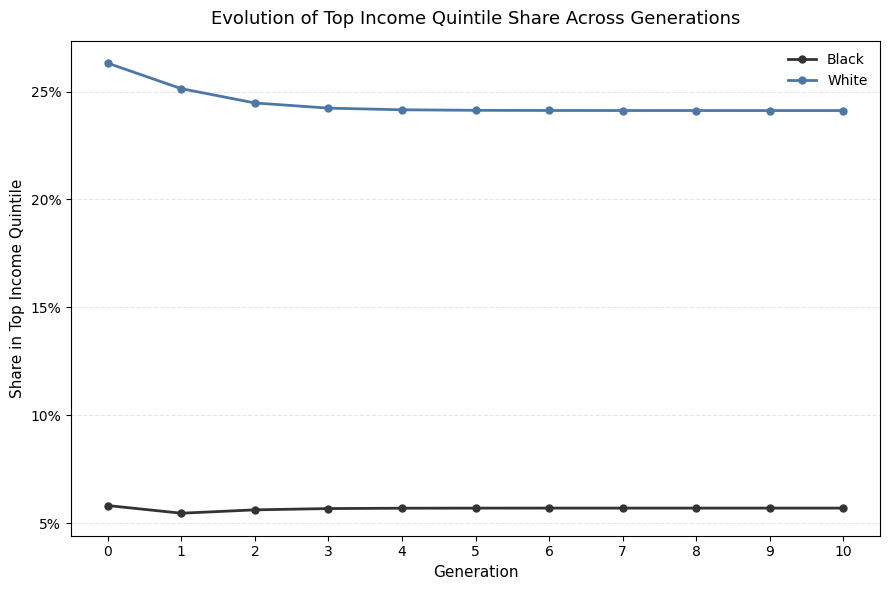

In [39]:
# QUESTION 3.5
# Evolution of the share in the top income quintile
# across generations.
# Generation 0 = parental income distribution
# Generation 1 = child income distribution
# ...
# Generation 10 = tenth subsequent generation


# Number of generations to display.
# Because generation 0 is included, this produces
# 11 observations: generations 0 through 10.
generations = 11


# Store top-quintile shares for each race
top_shares = {
    "Black": [],
    "White": []
}

# 1. Set generation 0 equal to the observed parental
#    income distribution.
# .copy() is used so that the original parental
# distributions are not modified.

distributions = {
    race: parent_dist[race].copy()
    for race in races
}


# 2. Iterate through generations

for generation in range(generations):

    # Record the share in the top income quintile.
    #
    # Q5 is the fifth element, which has index 4 in Python.

    for race in races:

        top_shares[race].append(
            distributions[race][4]
        )

    # Generate the next generation.
    # NewDist = TransitionMatrix @ CurrentDist

    for race in races:

        distributions[race] = (
            transition[race] @ distributions[race]
        )


        # The transition probabilities in the supplied
        # dataset are rounded, so their columns do not sum
        # to exactly 1. Normalize each new distribution
        # to maintain a valid probability distribution.
        distributions[race] = (
            distributions[race]
            / distributions[race].sum()
        )

# 3. Print top-quintile shares

print("Top Income Quintile Share by Generation")
print("=" * 60)

print(
    f"{'Generation':<12}"
    f"{'Black':>12}"
    f"{'White':>12}"
)

print("-" * 36)

for generation in range(generations):

    print(
        f"{generation:<12}"
        f"{top_shares['Black'][generation]:>12.4f}"
        f"{top_shares['White'][generation]:>12.4f}"
    )

# 4. Save top-quintile shares to output folder

df_top_quintile = pd.DataFrame({
    "Generation": list(range(generations)),
    "Black": top_shares["Black"],
    "White": top_shares["White"]
})

df_top_quintile.to_csv("../output/q3_top_quintile_shares.csv", index=False)

# 5. Create the plot

fig, ax = plt.subplots(
    figsize=(9, 6)
)


# Black
ax.plot(
    range(generations),
    top_shares["Black"],
    marker="o",
    markersize=5,
    linewidth=2,
    color="#333333",
    label="Black"
)


# White
ax.plot(
    range(generations),
    top_shares["White"],
    marker="o",
    markersize=5,
    linewidth=2,
    color="#4C78A8",
    label="White"
)

# 6. Labels and formatting

ax.set_xlabel(
    "Generation",
    fontsize=11
)

ax.set_ylabel(
    "Share in Top Income Quintile",
    fontsize=11
)

ax.set_title(
    "Evolution of Top Income Quintile Share Across Generations",
    fontsize=13,
    pad=12
)


# Show every generation on x-axis
ax.set_xticks(
    range(generations)
)


# Format y-axis as percentages
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, _: f"{y:.0%}"
    )
)


# Legend
ax.legend(
    frameon=False
)


# Light horizontal grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)


plt.tight_layout()

plt.show()

# 7. Save the plot to output folder

fig.savefig("../output/q3_top_quintile_plot.png",
            dpi=300,
            bbox_inches='tight')